# Sales Forecasting using Machine Learning

This project predicts future monthly sales using Machine Learning.
We transform time into a numerical feature and train a Linear Regression model
to forecast the next 12 months of sales.

In [23]:
import pandas as pd

df = pd.read_csv("Sample_ Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   str    
 2   Order Date    9994 non-null   str    
 3   Ship Date     9994 non-null   str    
 4   Ship Mode     9994 non-null   str    
 5   Customer ID   9994 non-null   str    
 6   Segment       9994 non-null   str    
 7   Country       9994 non-null   str    
 8   City          9994 non-null   str    
 9   State         9994 non-null   str    
 10  Region        9994 non-null   str    
 11  Product ID    9994 non-null   str    
 12  Category      9994 non-null   str    
 13  Sub-Category  9994 non-null   str    
 14  Product Name  9994 non-null   str    
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null   float64
d

In [25]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [27]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [34]:
# set it as index again
df = df.set_index('Order Date')

In [28]:
df['Order Date'].isna().sum()

np.int64(0)

In [29]:
df = df.sort_values('Order Date')

In [30]:
daily_sales = df.groupby('Order Date')['Sales'].sum()
daily_sales.head()

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64

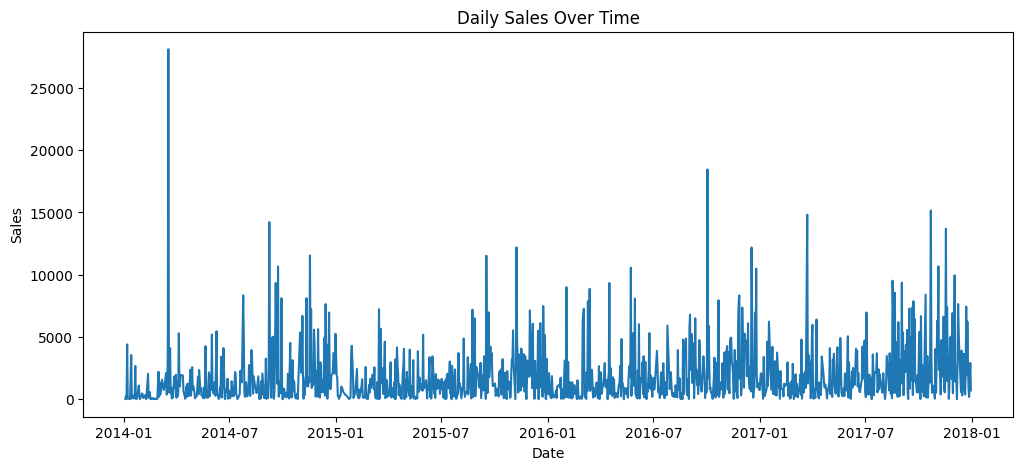

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [35]:

# monthly sales
monthly_sales = df['Sales'].resample('ME').sum()

monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

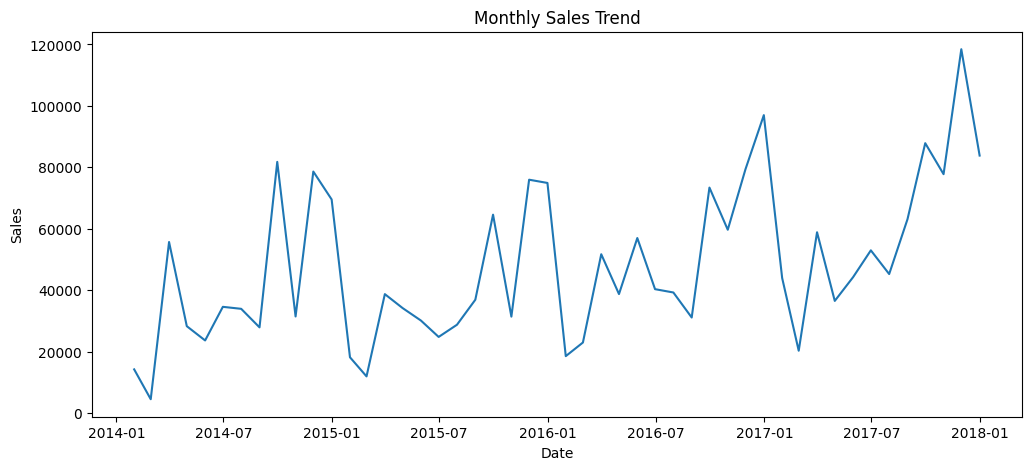

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

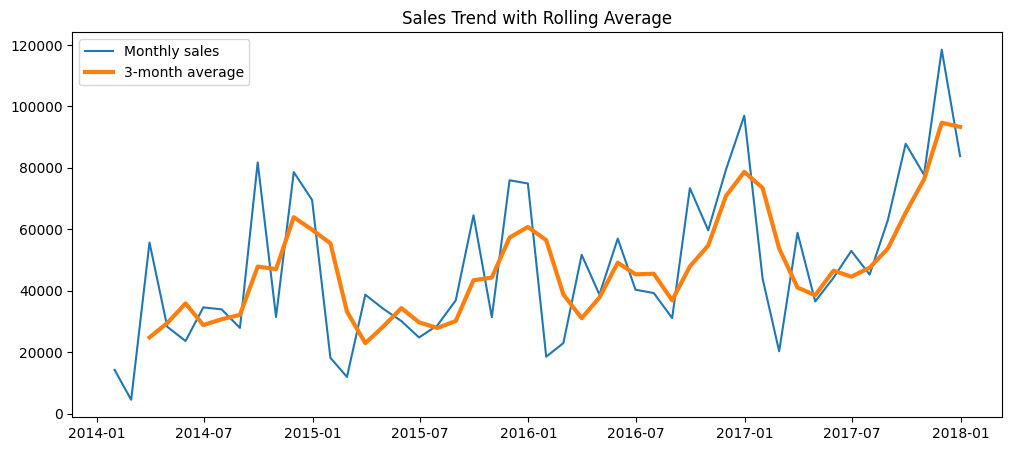

In [ ]:
rolling_mean = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales, label="Monthly sales")
plt.plot(rolling_mean, label="3-month average", linewidth=3)

plt.legend()
plt.title("Sales Trend with Rolling Average")
plt.show()

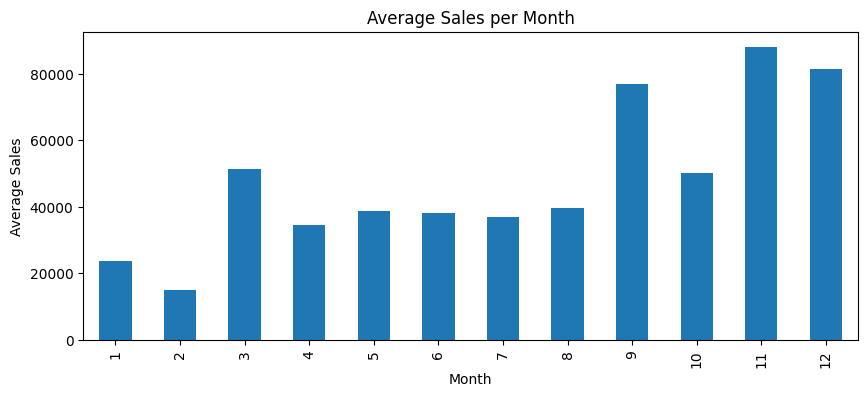

In [ ]:
monthly_sales.groupby(monthly_sales.index.month).mean().plot(kind='bar', figsize=(10,4))
plt.title("Average Sales per Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
monthly_sales = monthly_sales.reset_index()

monthly_sales['MonthNumber'] = range(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,MonthNumber
0,2014-01-31,14236.895,0
1,2014-02-28,4519.892,1
2,2014-03-31,55691.009,2
3,2014-04-30,28295.345,3
4,2014-05-31,23648.287,4


In [ ]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[['MonthNumber']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
future_months = pd.DataFrame({
    'MonthNumber': range(len(monthly_sales), len(monthly_sales)+12)
})

future_predictions = model.predict(future_months)
future_predictions

array([69957.53579787, 70859.54333018, 71761.55086249, 72663.55839481,
       73565.56592712, 74467.57345943, 75369.58099174, 76271.58852405,
       77173.59605636, 78075.60358867, 78977.61112098, 79879.61865329])

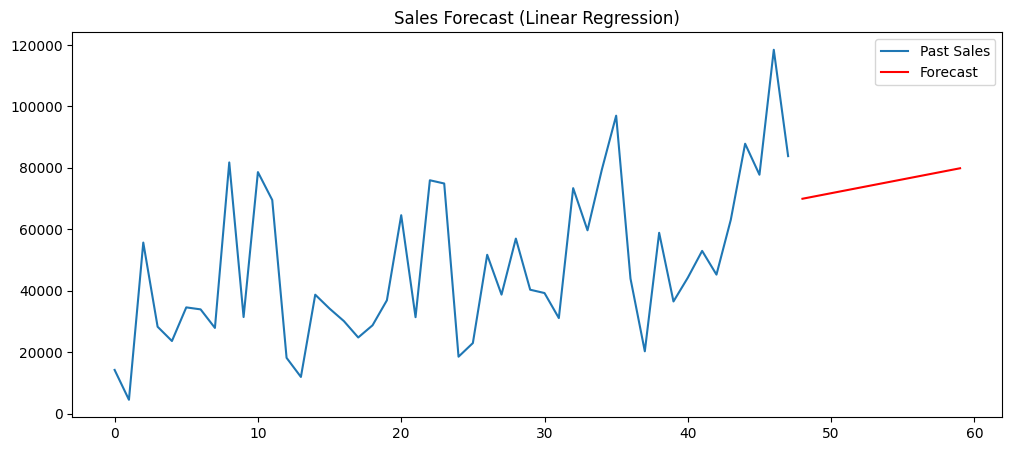

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['MonthNumber'], monthly_sales['Sales'], label='Past Sales')
plt.plot(future_months['MonthNumber'], future_predictions, label='Forecast', color='red')

plt.title("Sales Forecast (Linear Regression)")
plt.legend()
plt.show()